## Topic

Regime Changes; Statistical Uncertainty; Prediction Intervals

先读[Machine Learning Foundations](../Study%20topics/ml-foundations-start-here.html)，再读对应[双语讲义](../Study%20topics/regime-changes-statistical-uncertainty-prediction-intervals.html)。

## Question

What is Regime Changes; Statistical Uncertainty; Prediction Intervals, and how would you evaluate it?

本实验中的模型或评估方法是什么？它解决什么问题，又怎样检验效果？

讲义提供Key Terms、直观例子、英文Short Answer及紧接其后的中文回答。先理解问题，再运行下面的代码。


# Regime Changes; Statistical Uncertainty; Prediction Intervals

## Learning Goal

A mean metric can hide changing error regimes. Overlapping forecast labels create dependent errors. Block resampling preserves some local dependence; residual intervals calibrated in one regime may fail after a shift.

## Minimal Prerequisites

Basic Python arrays and functions. Run all cells in order; no API key or network data is required. Data are synthetic teaching fixtures, not empirical market evidence.

## Guided Experiment

Increase block length and compare paired-error confidence intervals. Calibrate a residual interval on the early regime and measure its coverage after the shift.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


nominal 90 percent, shifted coverage 0.4
paired mean interval [-0.1245291   0.03504712]


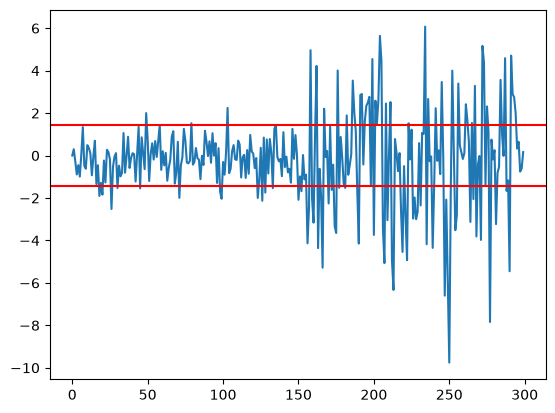

In [2]:
rng=np.random.default_rng(7);errors=np.r_[rng.normal(0,1,150),rng.normal(0,3,150)];q=np.quantile(abs(errors[:150]),.9)
print("nominal 90 percent, shifted coverage",np.mean(abs(errors[150:])<=q))
delta=np.convolve(rng.normal(.1,1,305),np.ones(6)/6,mode="valid");block=10;means=[]
for _ in range(400):
    starts=rng.integers(0,len(delta)-block+1,size=int(np.ceil(len(delta)/block)))
    sample=np.concatenate([delta[s:s+block] for s in starts])[:len(delta)];means.append(sample.mean())
print("paired mean interval",np.quantile(means,[.025,.975]));plt.plot(errors);plt.axhline(q,color="red");plt.axhline(-q,color="red");plt.show()

## Expected Observations

Coverage can collapse under distribution shift. Block length is a modeling choice; this toy bootstrap does not establish a universal uncertainty guarantee.

## Review Experiment

Before changing a parameter, write the direction you expect and why. Change only the parameter named in the guided experiment; rerun from a fresh kernel. Compare the observed result with your prediction. On a later review day, explain the code without reading the answers.

## English Check Questions

1. What quantity is this experiment estimating?
2. What information is available at prediction time?
3. Which observation would invalidate your conclusion?

## Reference Answers

1. A mean metric can hide changing error regimes. Overlapping forecast labels create dependent errors. Block resampling preserves some local dependence; residual intervals calibrated in one regime may fail after a shift.
2. Training inputs and their labels must be available before the relevant evaluation origin; preprocessing is fitted on training data only.
3. Coverage can collapse under distribution shift. Block length is a modeling choice; this toy bootstrap does not establish a universal uncertainty guarantee.

## Financial Connection

Transfer the timing, metric or deployment contract to the five-day volatility Workbench. A toy experiment verifies mechanics, not trading profitability.

## Sources

- https://scikit-learn.org/stable/common_pitfalls.html
- https://scikit-learn.org/stable/modules/cross_validation.html
- https://scikit-learn.org/stable/modules/model_evaluation.html

[Return to study page](../Study%20topics/regime-changes-statistical-uncertainty-prediction-intervals.html)
